# Repair Results Analysis

This notebook loads repair results from SQLite databases and generates summary statistics and visualizations.


In [63]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
%matplotlib inline

In [65]:
database_version = "14"

In [66]:
target_db = f'targets{database_version}.db'

In [67]:
sources_dbs = [
            "repair_results_ollama_llama3:70b_targets14.db",
            "repair_results_openai_gpt-4.1-2025-04-14_targets14.db",
            "repair_results_openai_o4-mini-2025-04-16_targets14.db"
            ]

In [68]:
import sqlite3
conn = sqlite3.connect(target_db)
# Note: cases.id in targets DB corresponds to source puzzle.id
df_cases = pd.read_sql(
    "SELECT id AS puzzle_id, num_nonterminals, nonterminal_prob, loop_prob, mutation_depth, original_parser, corrupted_grammar FROM cases",
    conn
)

# Compute derived columns for analysis
df_cases['parser_size'] = df_cases['original_parser'].str.len()
df_cases['corrupted_symbol_count'] = df_cases['corrupted_grammar'].str.split().str.len()

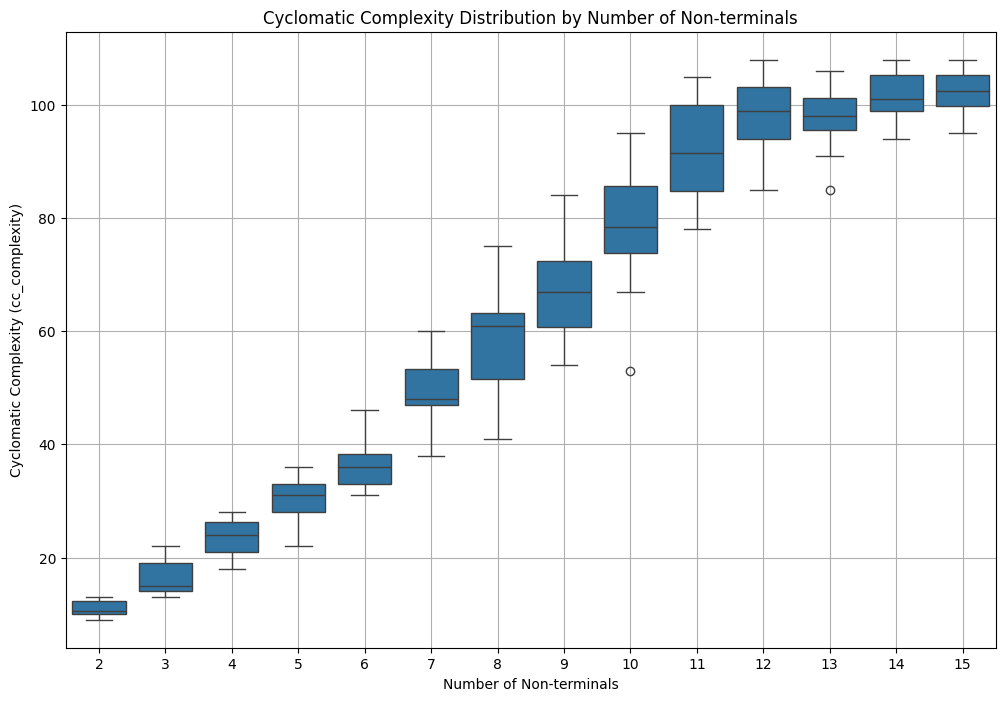

In [69]:
db_file = f'targets{database_version}.db'
conn = sqlite3.connect(db_file)

# Query the data
query = "SELECT num_nonterminals, cc_complexity FROM cases WHERE cc_complexity IS NOT NULL"
df = pd.read_sql_query(query, conn)

# Close the connection
conn.close()

# Create the plot
plt.figure(figsize=(12, 8))
sns.boxplot(x='num_nonterminals', y='cc_complexity', data=df)

# Set titles and labels
plt.title('Cyclomatic Complexity Distribution by Number of Non-terminals')
plt.xlabel('Number of Non-terminals')
plt.ylabel('Cyclomatic Complexity (cc_complexity)')
plt.grid(True)
plt.show()

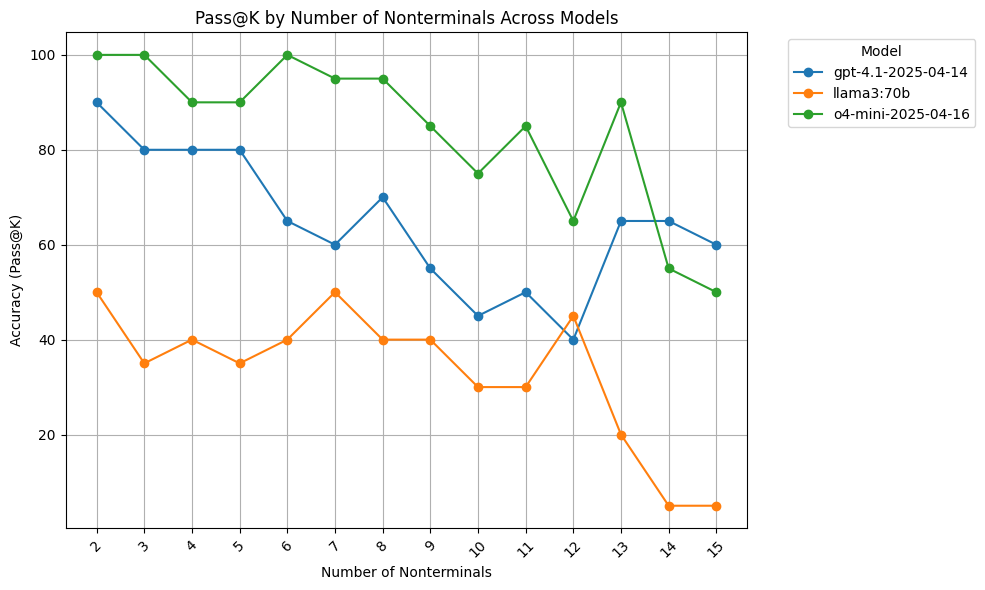

In [70]:
import matplotlib.pyplot as plt

# Preprocessing: ensure num_nonterminals is integer and clean data
df_cases['num_nonterminals'] = pd.to_numeric(df_cases['num_nonterminals'], errors='coerce')
df_cases = df_cases.dropna(subset=['num_nonterminals'])
df_cases['num_nonterminals'] = df_cases['num_nonterminals'].astype(int)

all_num_nts = sorted(df_cases['num_nonterminals'].unique())

# Mapping from puzzle_id to num_nonterminals
case_nt = df_cases[['puzzle_id', 'num_nonterminals']].rename(columns={'puzzle_id': 'case_id'})

records = []
models = []

# Pre-calculate denominator for each number of nonterminals (total unique puzzles)
denom = df_cases.groupby('num_nonterminals')['puzzle_id'].nunique()

for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_') \
             .removesuffix(f'_targets{database_version}.db').split('_')[1]
    models.append(model)

    with sqlite3.connect(db_path) as conn:
        df_res = pd.read_sql('SELECT case_id, correct FROM repair_results', conn)

    # For pass@K: each puzzle counts as passed if it succeeded at least once
    passed_by_case = (df_res.groupby('case_id')['correct'].max() > 0).rename('passed').reset_index()
    df_join = passed_by_case.merge(case_nt, on='case_id', how='left')

    # Numerator: number of unique puzzles passed for each num_nonterminals
    num_passed = df_join.groupby('num_nonterminals')['passed'].sum()

    pass_rate = (num_passed / denom * 100).reindex(all_num_nts, fill_value=0)

    for num_nt, rate in pass_rate.items():
        records.append({'model': model, 'num_nonterminals': num_nt, 'pass_at_k': rate})

df_nt_passk = pd.DataFrame(records)

# Plotting
plt.figure(figsize=(10, 6))
for model in sorted(set(models)):
    df_model = df_nt_passk[df_nt_passk['model'] == model].sort_values('num_nonterminals')
    plt.plot(df_model['num_nonterminals'], df_model['pass_at_k'], marker='o', label=model)

plt.xlabel('Number of Nonterminals')
plt.ylabel('Accuracy (Pass@K)')
plt.title('Pass@K by Number of Nonterminals Across Models')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(all_num_nts, rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [71]:
# import matplotlib.pyplot as plt

# df_cases['num_nonterminals'] = pd.to_numeric(df_cases['num_nonterminals'], errors='coerce')
# df_cases = df_cases.dropna(subset=['num_nonterminals'])
# df_cases['num_nonterminals'] = df_cases['num_nonterminals'].astype(int)

# all_num_nts = sorted(df_cases['num_nonterminals'].unique())
# models = df_nt_correctedes['model'].unique()

# for model in models:
#     df_model_raw = df_nt_correctedes[df_nt_correctedes['model'] == model]
#     df_model = pd.DataFrame({'num_nonterminals': all_num_nts})
#     df_model = df_model.merge(df_model_raw[['num_nonterminals', 'accuracy']], on='num_nonterminals', how='left')
#     df_model['accuracy'] = df_model['accuracy'].fillna(0).astype(int)
    
#     plt.figure(figsize=(10, 6))
#     plt.plot(df_model['num_nonterminals'], df_model['accuracy'], marker='o', linestyle='-')


#     plt.title(f'Accuracy for {model} by Number of Nonterminals')
#     plt.xlabel('Number of Nonterminals')
#     plt.ylabel('Accuracy')
#     plt.xticks(all_num_nts, rotation=45)
#     # plt.ylim(0, 100)
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

In [72]:
# # Bar plot of average mutation_depth vs num_nonterminals
# avg_mut = df_cases.groupby('num_nonterminals')['mutation_depth'].mean().reset_index()
# plt.figure(figsize=(8, 6))
# sns.barplot(data=avg_mut, x='num_nonterminals', y='mutation_depth', palette='tab10')
# plt.xlabel('Number of Nonterminals')
# plt.ylabel('Average Mutation Depth')
# plt.title('Average Mutation Depth vs Number of Nonterminals')
# plt.tight_layout()


In [73]:
# # Combined heatmap of corrected-rate across all models by nonterminal_prob and loop_prob
# records = []
# for db_path in sources_dbs:
#     conn = sqlite3.connect(db_path)
#     df_res = pd.read_sql(
#         'SELECT nonterminal_prob, loop_prob, corrected FROM repair_results', conn
#     )
#     conn.close()
#     df_res['model'] = os.path.basename(db_path)
#     records.append(df_res)

# df_all = pd.concat(records, ignore_index=True)

# totals = df_all.groupby(['nonterminal_prob','loop_prob']).size().rename('total')
# successes= df_all[df_all['corrected'] == 1].groupby(['nonterminal_prob','loop_prob']).size().rename('success')
# df_rate = pd.concat([totals, successes], axis=1).fillna(0)
# df_rate['rate'] = df_rate['success'] / df_rate['total']
# pivot = df_rate['rate'].unstack(level='loop_prob')

# plt.figure(figsize=(6, 5))
# sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
# plt.title('Combined corrected Rate Across All Models')
# plt.xlabel('loop_prob')
# plt.ylabel('nonterminal_prob')
# plt.tight_layout()


In [74]:
# # Scatter plot of parser_size vs corrupted_symbol_count, highlighting correcteded cases per model
# for db_path in sources_dbs:
#     model = os.path.basename(db_path).removeprecorrected('repair_results_').removesufcorrected('_targets.db')
#     conn = sqlite3.connect(db_path)
#     df_res = pd.read_sql(
#         'SELECT case_id, corrected FROM repair_results', conn
#     )
#     conn.close()
#     correcteded = df_res[df_res['corrected'] == 1]['case_id']
#     plt.figure(figsize=(6, 5))
#     sns.scatterplot(data=df_cases, x='corrupted_symbol_count', y='parser_size', alpha=0.3, label='All cases')
#     sns.scatterplot(data=df_cases[df_cases['puzzle_id'].isin(correcteded)], 
#                     x='corrupted_symbol_count', y='parser_size', color='red', label='correcteded cases')
#     plt.title(f'Parser Size vs Symbol Count (correcteded) for {model}')
#     plt.xlabel('Symbol Count')
#     plt.ylabel('Parser Size')
#     plt.legend()
#     plt.tight_layout()


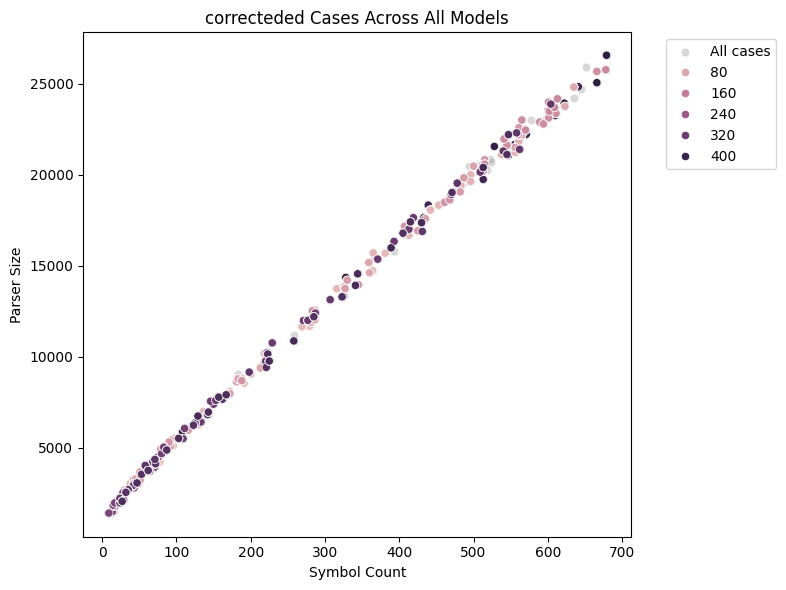

In [75]:
# Combined scatter plot of correcteded cases across all models
records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_') \
             .removesuffix(f'_targets{database_version}.db').split('_')[1]
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql('SELECT case_id, puzzle_id, correct, total_tokens FROM repair_results', conn)
    # Merge using cases.id (puzzle_id) mapping to source puzzle.id
    df_tmp = df_res[df_res['correct'] == 1].merge(df_cases, left_on='case_id', right_on='puzzle_id')
    df_tmp['model'] = model
    records.append(df_tmp)
    conn.close()

df_correcteded_all = pd.concat(records, ignore_index=True)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cases, x='corrupted_symbol_count', y='parser_size', color='gray', alpha=0.3, label='All cases')
sns.scatterplot(data=df_correcteded_all, x='corrupted_symbol_count', y='parser_size', hue='puzzle_id_x')
plt.xlabel('Symbol Count')
plt.ylabel('Parser Size')
plt.title('correcteded Cases Across All Models')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


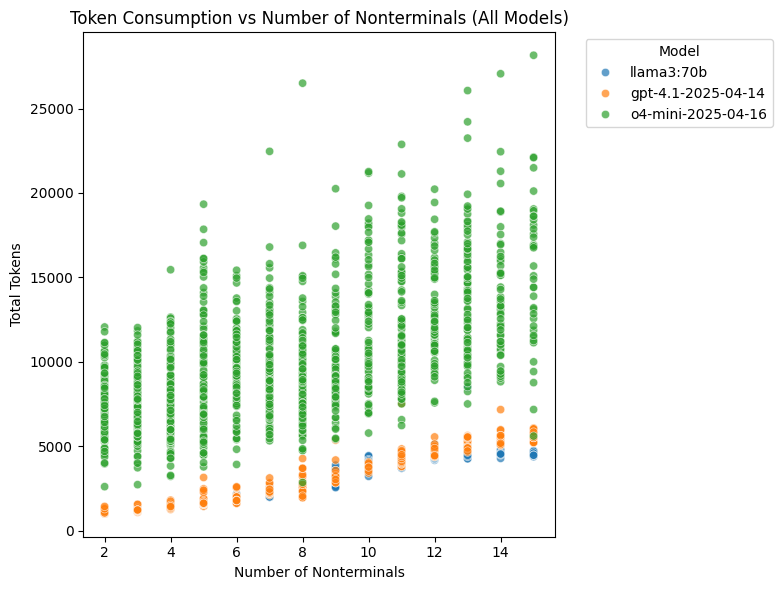

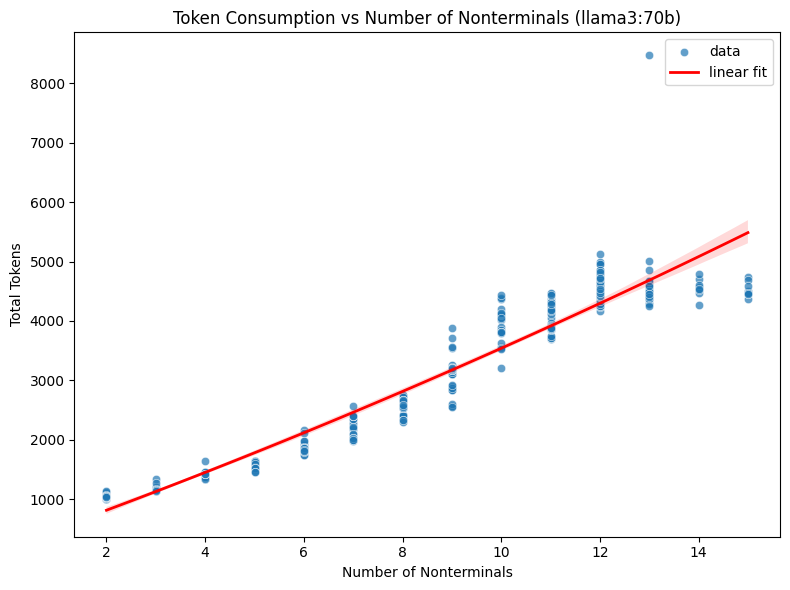

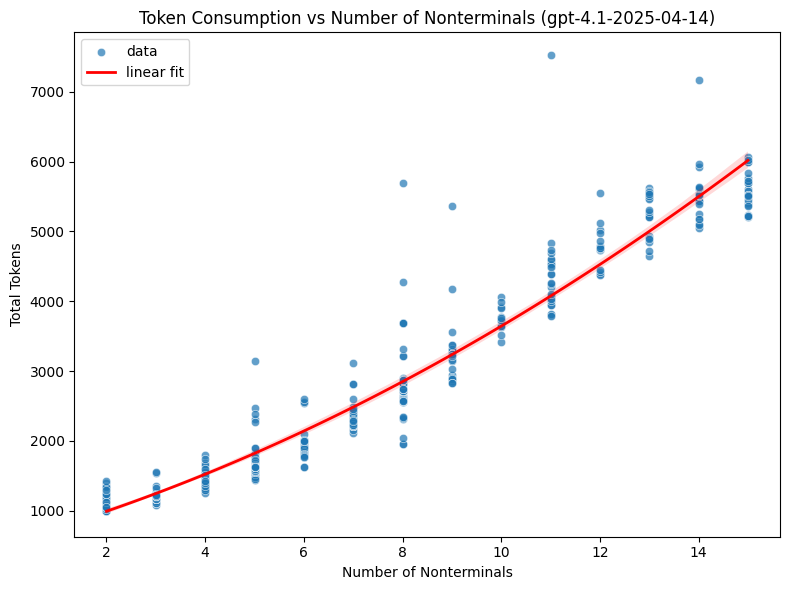

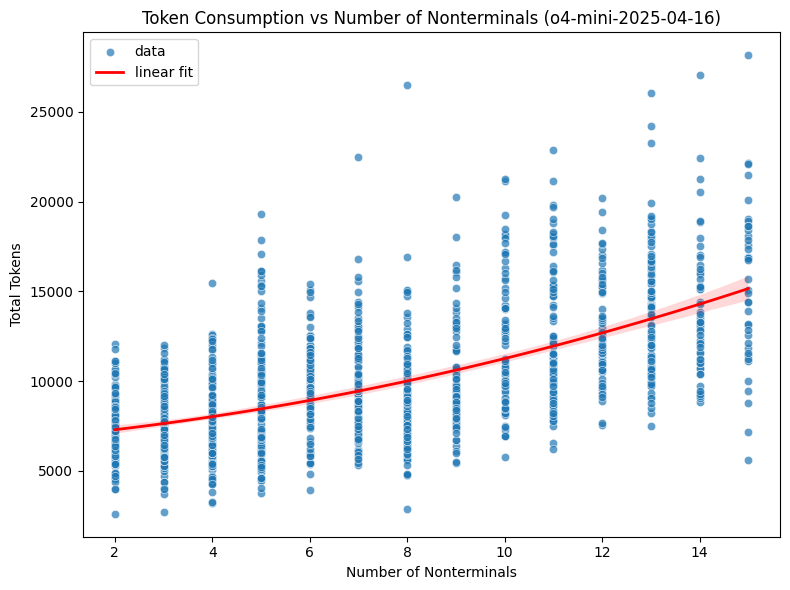

In [76]:
# Scatter plot of token consumption vs number of nonterminals across all correcteded cases
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_correcteded_all, x='num_nonterminals', y='total_tokens', hue='model', alpha=0.7)
plt.xlabel('Number of Nonterminals')
plt.ylabel('Total Tokens')
plt.title('Token Consumption vs Number of Nonterminals (All Models)')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Individual model plots with linear fit
for model in df_correcteded_all['model'].unique():
    df_mod = df_correcteded_all[df_correcteded_all['model'] == model]
    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        data=df_mod,
        x='num_nonterminals',
        y='total_tokens',
        color='C0',
        alpha=0.7,
        label='data'
    )
    sns.regplot(
        data=df_mod,
        x='num_nonterminals',
        y='total_tokens',
        scatter=False,      # 不画散点
        line_kws={'color': 'red', 'lw': 2},
        label='linear fit',
        order=2
    )

    plt.xlabel('Number of Nonterminals')
    plt.ylabel('Total Tokens')
    plt.title(f'Token Consumption vs Number of Nonterminals ({model})')
    plt.legend()
    plt.tight_layout()
    plt.show()


/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seabo

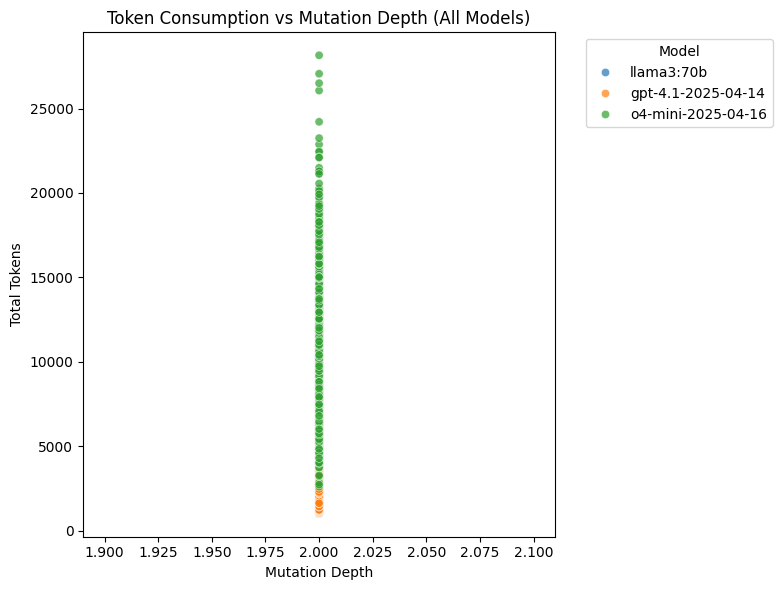

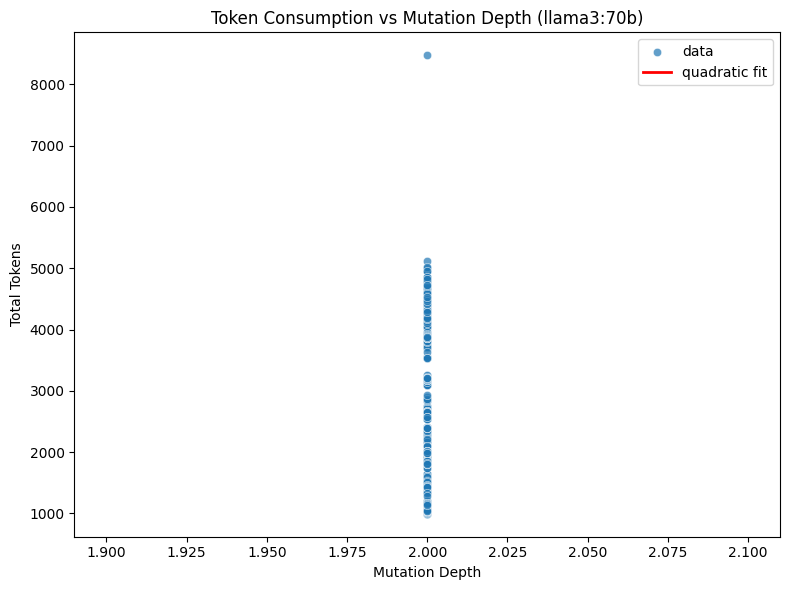

/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seaborn/regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
/Users/jack/Grammar_bench/venv/lib/python3.12/site-packages/seabo

KeyboardInterrupt: 

In [77]:
# Scatter plot of token consumption vs mutation depth across all correcteded cases
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_correcteded_all, x='mutation_depth', y='total_tokens', hue='model', alpha=0.7)
plt.xlabel('Mutation Depth')
plt.ylabel('Total Tokens')
plt.title('Token Consumption vs Mutation Depth (All Models)')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Individual model plots with quadratic fit
for model in df_correcteded_all['model'].unique():
    df_mod = df_correcteded_all[df_correcteded_all['model'] == model]
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_mod, x='mutation_depth', y='total_tokens', color='C0', alpha=0.7, label='data')
    sns.regplot(data=df_mod, x='mutation_depth', y='total_tokens', scatter=False, line_kws={'color': 'red', 'lw': 2}, label='quadratic fit', order=2)
    plt.xlabel('Mutation Depth')
    plt.ylabel('Total Tokens')
    plt.title(f'Token Consumption vs Mutation Depth ({model})')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Table of correcteded cases counts by mutation_depth for each model
records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprecorrected('repair_results_').removesufcorrected('_targets.db')
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql('SELECT case_id, corrected FROM repair_results', conn)
    conn.close()
    df_ok = df_res[df_res['corrected'] == 1].merge(df_cases[['puzzle_id','mutation_depth']], left_on='case_id', right_on='puzzle_id')
    counts = df_ok['mutation_depth'].value_counts().sort_index()
    for depth, cnt in counts.items():
        records.append({'model': model, 'mutation_depth': depth, 'accuracy': cnt})

df_mut_counts = pd.DataFrame(records)
pivot_mut = df_mut_counts.pivot(index='mutation_depth', columns='model', values='accuracy').fillna(0).astype(int)
print(pivot_mut)


model           gemini_gemini-2.5-flash_targets6.db  \
mutation_depth                                        
1                                                41   
2                                                49   
3                                                32   
4                                                 9   
5                                                 4   

model           ollama_llama3:70b_targets6.db  \
mutation_depth                                  
1                                          29   
2                                          14   
3                                          13   
4                                           7   
5                                           3   

model           openai_gpt-4.1-2025-04-14_targets6.db  
mutation_depth                                         
1                                                  11  
2                                                  13  
3                                             

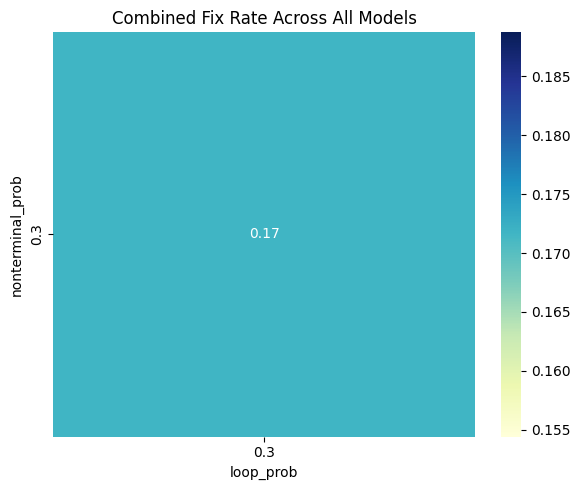

In [ ]:
records = []
for db_path in sources_dbs:
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql(
        'SELECT nonterminal_prob, loop_prob, corrected FROM repair_results', conn
    )
    conn.close()
    df_res['model'] = os.path.basename(db_path)
    records.append(df_res)

df_all = pd.concat(records, ignore_index=True)

# compute total & successful counts per (nonterminal_prob, loop_prob)
totals    = df_all.groupby(['nonterminal_prob','loop_prob']).size().rename('total')
successes = df_all[df_all['corrected'] == 1] \
                    .groupby(['nonterminal_prob','loop_prob']).size().rename('success')
df_rate   = pd.concat([totals, successes],
axis=1).fillna(0)
df_rate['rate'] = df_rate['success'] / df_rate['total']

# pivot into heatmap-friendly form
pivot = df_rate['rate'].unstack(level='loop_prob')

# plot
plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Combined corrected Rate Across All Models')
plt.xlabel('loop_prob')
plt.ylabel('nonterminal_prob')
plt.tight_layout()

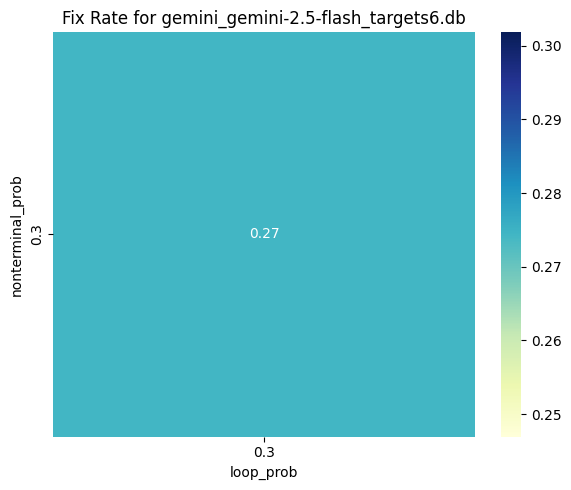

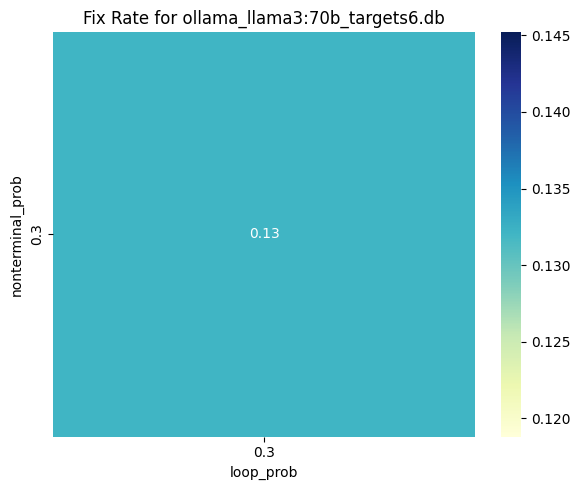

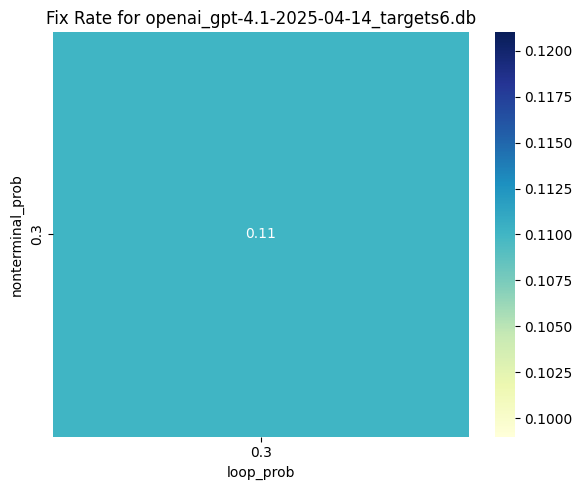

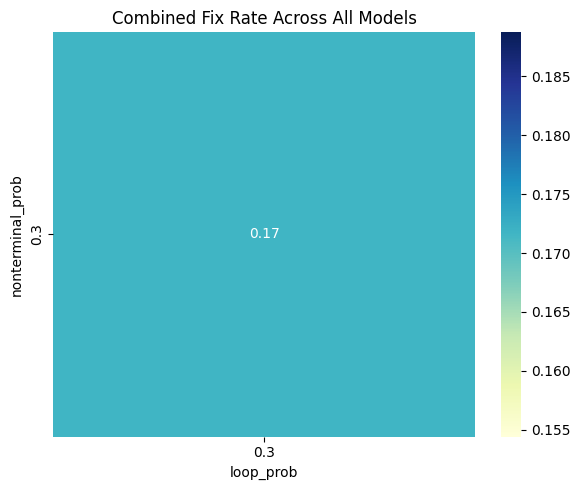

In [ ]:
# for db_path in sources_dbs:
#         model = os.path.basename(db_path).removeprecorrected('repair_results_') \
#                              .removesufcorrected('_targets.db')
#         conn = sqlite3.connect(db_path)
#         df_res = pd.read_sql(
#             'SELECT nonterminal_prob, loop_prob, corrected FROM repair_results',
#             conn
#         )
#         conn.close()

#         # Compute success rate per (nonterminal_prob, loop_prob)
#         totals   = df_res.groupby(['nonterminal_prob','loop_prob']).size().rename('total')
#         successes= df_res[df_res['corrected'] == 1] \
#                         .groupby(['nonterminal_prob','loop_prob']).size().rename('success')
#         df_rate  = pd.concat([totals, successes], axis=1).fillna(0)
#         df_rate['rate'] = df_rate['success'] / df_rate['total']

#         # Pivot for heatmap
#         pivot = df_rate['rate'].unstack(level='loop_prob')

#         plt.figure(figsize=(6, 5))
#         sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
#         plt.title(f'corrected Rate for {model}')
#         plt.xlabel('loop_prob')
#         plt.ylabel('nonterminal_prob')
#         plt.tight_layout()

# # Combined heatmap of corrected-rate across all models by nonterminal_prob and loop_prob
# records = []
# for db_path in sources_dbs:
#     conn = sqlite3.connect(db_path)
#     df_res = pd.read_sql(
#         'SELECT nonterminal_prob, loop_prob, corrected FROM repair_results',
#         conn
#     )
#     conn.close()
#     df_res['model'] = os.path.basename(db_path)
#     records.append(df_res)

# df_all = pd.concat(records, ignore_index=True)

# # Compute aggregated success rate
# totals   = df_all.groupby(['nonterminal_prob','loop_prob']).size().rename('total')
# successes= df_all[df_all['corrected'] == 1] \
#                 .groupby(['nonterminal_prob','loop_prob']).size().rename('success')
# df_rate  = pd.concat([totals, successes], axis=1).fillna(0)
# df_rate['rate'] = df_rate['success'] / df_rate['total']

# # Pivot for combined heatmap
# pivot = df_rate['rate'].unstack(level='loop_prob')

# plt.figure(figsize=(6, 5))
# sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
# plt.title('Combined corrected Rate Across All Models')
# plt.xlabel('loop_prob')
# plt.ylabel('nonterminal_prob')
# plt.tight_layout()


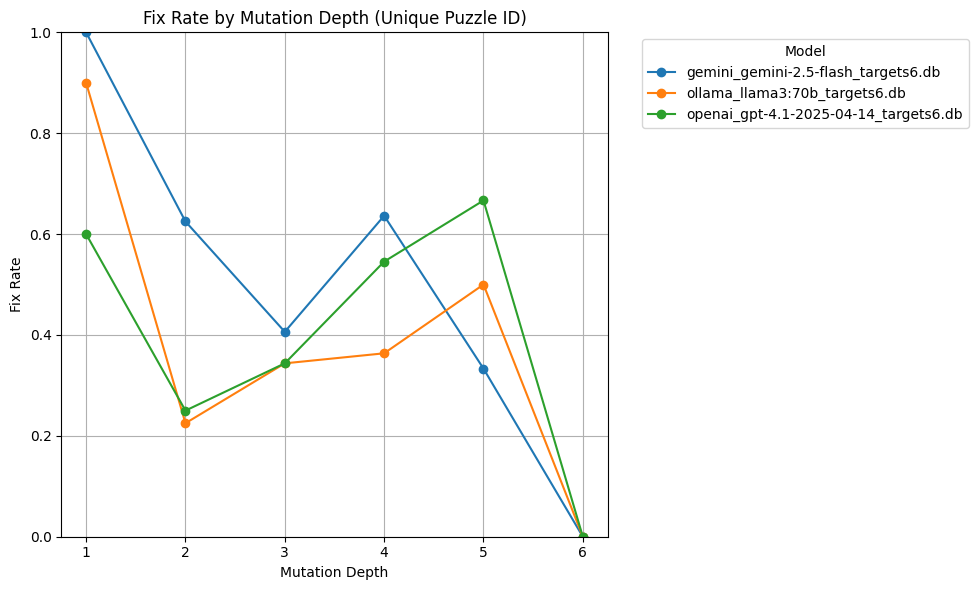

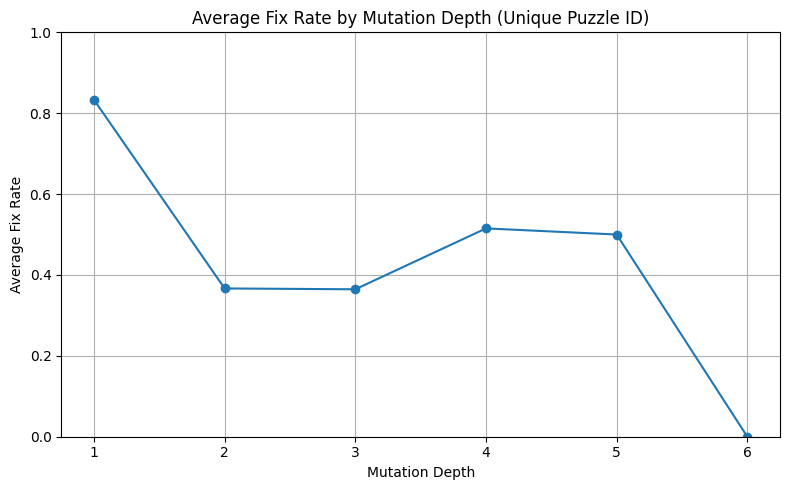

In [ ]:
import matplotlib.pyplot as plt

# Step 1: 统计每个模型成功修复的 puzzle（按 mutation_depth）
records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprecorrected('repair_results_') \
                                     .removesufcorrected('_targets.db')
    conn = sqlite3.connect(db_path)
    try:
        df_res = pd.read_sql("SELECT case_id, corrected FROM repair_results", conn)
    except pd.io.sql.DatabaseError:
        conn.close()
        continue
    conn.close()

    # Merge on puzzle_id (cases.id) and case_id
    df_merged = df_res[df_res['corrected'] == 1].merge(
        df_cases[['puzzle_id', 'mutation_depth']],
        left_on='case_id', right_on='puzzle_id'
    )

    # 按 puzzle_id 去重，避免重复计入多个 case
    df_unique = df_merged.drop_duplicates(subset='puzzle_id')
    counts = df_unique['mutation_depth'].value_counts().sort_index()
    for depth, cnt in counts.items():
        records.append({'model': model, 'mutation_depth': depth, 'corrected_count': cnt})

df_counts = pd.DataFrame(records)

# Step 2: 计算 total_cases（按 puzzle_id 去重）
df_unique_puzzles = df_cases.drop_duplicates(subset='puzzle_id')
total_cases = df_unique_puzzles['mutation_depth'].value_counts().sort_index().to_dict()
all_depths = sorted(total_cases.keys())
all_models = df_counts['model'].unique()

# Step 3: 构造完整的 corrected_rate 表格
full_records = []
for model in all_models:
    model_df = df_counts[df_counts['model'] == model].set_index('mutation_depth')['corrected_count'].to_dict()
    for depth in all_depths:
        corrected_count = model_df.get(depth, 0)
        total = total_cases.get(depth, 0)
        rate = corrected_count / total if total > 0 else 0
        full_records.append({'model': model, 'mutation_depth': depth, 'corrected_rate': rate})

df_rates = pd.DataFrame(full_records)

# Step 4: 绘图（每个模型折线）
plt.figure(figsize=(10, 6))
for model in df_rates['model'].unique():
    df_model = df_rates[df_rates['model'] == model].sort_values('mutation_depth')
    plt.plot(df_model['mutation_depth'], df_model['corrected_rate'], marker='o', label=model)

plt.xlabel('Mutation Depth')
plt.ylabel('corrected Rate')
plt.title('corrected Rate by Mutation Depth (Unique Puzzle ID)')
plt.xticks(all_depths)
plt.ylim(0, 1)
plt.grid(True)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Step 5: 绘图（所有模型的平均宽松准确率）
df_avg = df_rates.groupby('mutation_depth')['corrected_rate'].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(df_avg['mutation_depth'], df_avg['corrected_rate'], marker='o', linestyle='-')
plt.xlabel('Mutation Depth')
plt.ylabel('Average corrected Rate')
plt.title('Average corrected Rate by Mutation Depth (Unique Puzzle ID)')
plt.xticks(all_depths)
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

Pass@K

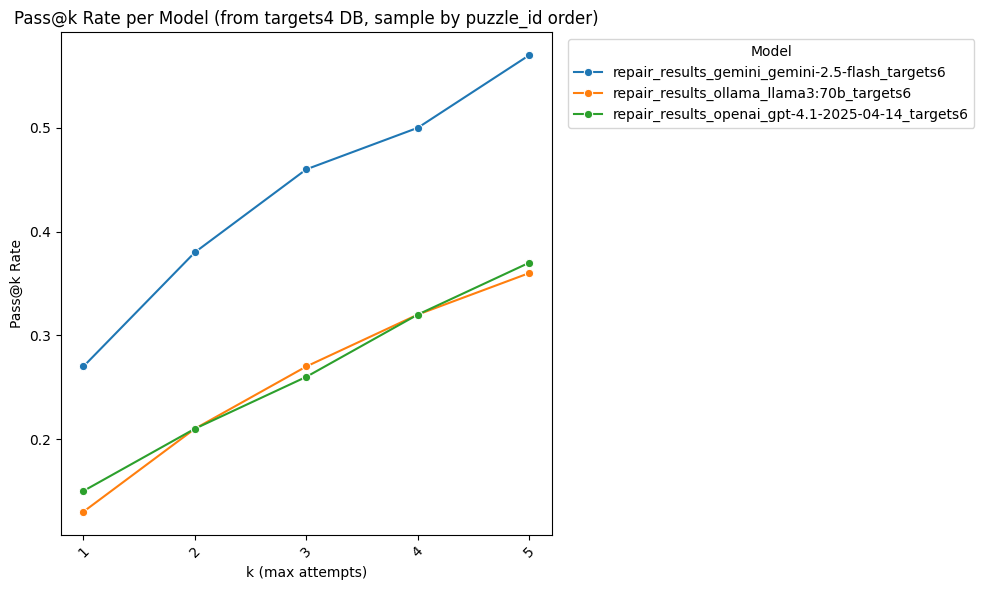

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

db_paths = [
 "repair_results_gemini_gemini-2.5-flash_targets6.db",
"repair_results_ollama_llama3:70b_targets6.db",
"repair_results_openai_gpt-4.1-2025-04-14_targets6.db"
]
ks = list(range(1, 6))
records = []

for db_path in db_paths:
    model = os.path.splitext(os.path.basename(db_path))[0]
    conn = sqlite3.connect(db_path)

    # Skip if there's no repair_results table
    existing = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table' AND name='repair_results'",
        conn
    )
    if existing.empty:
        print(f"{db_path} has no repair_results table, skipping…")
        conn.close()
        continue

    # Check if 'sample' column exists
    info = pd.read_sql("PRAGMA table_info(repair_results)", conn)
    has_sample = 'sample' in info['name'].tolist()

    # Read required columns
    cols = "puzzle_id, corrected" + (", sample" if has_sample else "")
    df = pd.read_sql(f"SELECT {cols} FROM repair_results", conn)
    conn.close()

    # If no sample column, assign sample numbers by puzzle_id occurrence order
    if not has_sample:
        df['sample'] = df.groupby('puzzle_id').cumcount() + 1

    total = df['puzzle_id'].nunique()
    for k in ks:
        df_k = df[df['sample'] <= k]
        # For each puzzle_id, if any of the first k attempts correcteded it, count as passed
        passed = df_k.groupby('puzzle_id')['corrected'].max().sum()
        rate = passed / total
        records.append({"model": model, "k": k, "rate": rate})

df_pass_k = pd.DataFrame(records)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_pass_k, x='k', y='rate', hue='model', marker='o')
plt.xticks(ks, rotation=45)
plt.xlabel('k (max attempts)')
plt.ylabel('Pass@k Rate')
plt.title('Pass@k Rate per Model (from targets4 DB, sample by puzzle_id order)')
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()